# Mapping Economic Expansion in Portugal (2012 vs 2016)
## Building a Cloud-Native Geospatial Pipeline using NASA's Black Marble Nightlights

## Project Overview

Nighttime light (NTL) satellite imagery is widely used by economists and data scientists as a highly accurate proxy for urbanization, economic growth, and energy consumption. 

Instead of relying on proprietary, black-box platforms like Google Earth Engine, this project builds an independent, 100% open-source Python pipeline. Using `leafmap`, `rasterio`, and `numpy`, this notebook connects directly to NASA’s Global Imagery Browse Services (GIBS) API to fetch, process, and analyze high-resolution VIIRS "Black Marble" composites for the country of Portugal.

**The goals of this analysis are:**
1. Programmatically extract cloud-free nightlight data without manual GIS downloads.
2. Build an interactive web map to visually track electrification over a 4-year period.
3. Perform mathematical raster operations to generate an "Urban Growth Heatmap" isolating zones of rapid development.

## Import libraries

In [1]:
import os
import leafmap
import rasterio
import numpy as np
import matplotlib.pyplot as plt

## Automated Data Sourcing (NASA GIBS)
To perform accurate mathematical analysis, we need clean, cloud-free data. Instead of processing raw daily satellite feeds, we are tapping into NASA's pre-computed "Black Marble" baselines for 2012 and 2016. 

The code below establishes a bounding box for Portugal and programmatically downloads the map tiles into local Cloud-Optimized GeoTIFFs.

In [2]:
os.makedirs("data", exist_ok=True)

# Bounding Box for Portugal
portugal_bbox = [-9.5, 36.9, -6.1, 42.1] 

url_2012 = "https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/VIIRS_CityLights_2012/default//GoogleMapsCompatible_Level8/{z}/{y}/{x}.jpg"
url_2016 = "https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/VIIRS_Black_Marble/default//GoogleMapsCompatible_Level8/{z}/{y}/{x}.png"

print("Downloading 2012 Nightlights... Please wait.")
leafmap.map_tiles_to_geotiff("data/lights_2012.tif", bbox=portugal_bbox, zoom=8, source=url_2012, overwrite=True)

print("Downloading 2016 Nightlights... Please wait.")
leafmap.map_tiles_to_geotiff("data/lights_2016.tif", bbox=portugal_bbox, zoom=8, source=url_2016, overwrite=True)

print("Downloads complete!")

Downloaded image 1/18
Downloaded image 2/18
Downloaded image 3/18
Downloaded image 4/18
Downloaded image 5/18
Downloaded image 6/18
Downloaded image 7/18
Downloaded image 8/18
Downloaded image 9/18
Downloaded image 10/18
Downloaded image 11/18
Downloaded image 12/18
Downloaded image 13/18
Downloaded image 14/18
Downloaded image 15/18
Downloaded image 16/18
Downloaded image 17/18
Downloaded image 18/18
Saving GeoTIFF. Please wait...
Image saved to data/lights_2012.tif
Downloaded image 1/18
Downloaded image 2/18
Downloaded image 3/18
Downloaded image 4/18
Downloaded image 5/18
Downloaded image 6/18
Downloaded image 7/18
Downloaded image 8/18
Downloaded image 9/18
Downloaded image 10/18
Downloaded image 11/18
Downloaded image 12/18
Downloaded image 13/18
Downloaded image 14/18
Downloaded image 15/18
Downloaded image 16/18
Downloaded image 17/18
Downloaded image 18/18
Saving GeoTIFF. Please wait...
Image saved to data/lights_2016.tif
Downloads complete!


## The Interactive Time Machine
Before running complex mathematics, it is crucial to visually explore the data. Using `leafmap`, we can stream the NASA map tiles into an interactive, split-panel web map directly inside the notebook. 

*Drag the slider left and right to visually compare Portugal's light footprint in 2012 versus 2016.*

In [3]:
# Create an interactive map centered on Portugal
Map = leafmap.Map(center=[39.5, -8.0], zoom=6)

# Add the interactive swipe tool comparing 2012 vs 2016
Map.split_map(
    left_layer=url_2012, 
    right_layer=url_2016
)

Map

Map(center=[39.5, -8.0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

## Generating the Urban Growth Heatmap
Visual exploration is helpful, but data science requires quantifiable metrics. To find exactly where Portugal grew the fastest, we must calculate the mathematical difference between the two eras.

Because the satellite images are essentially massive 2D arrays of numbers (where 0 is dark and 255 is maximum brightness), we use `rasterio` to open the files and `numpy` to subtract the 2012 pixel values from the 2016 pixel values. 

* Any pixel with a high positive number indicates new light (urban expansion).
* We apply a `numpy` mask to ignore the ocean and deep forests, forcing the algorithm to focus only on populated areas.

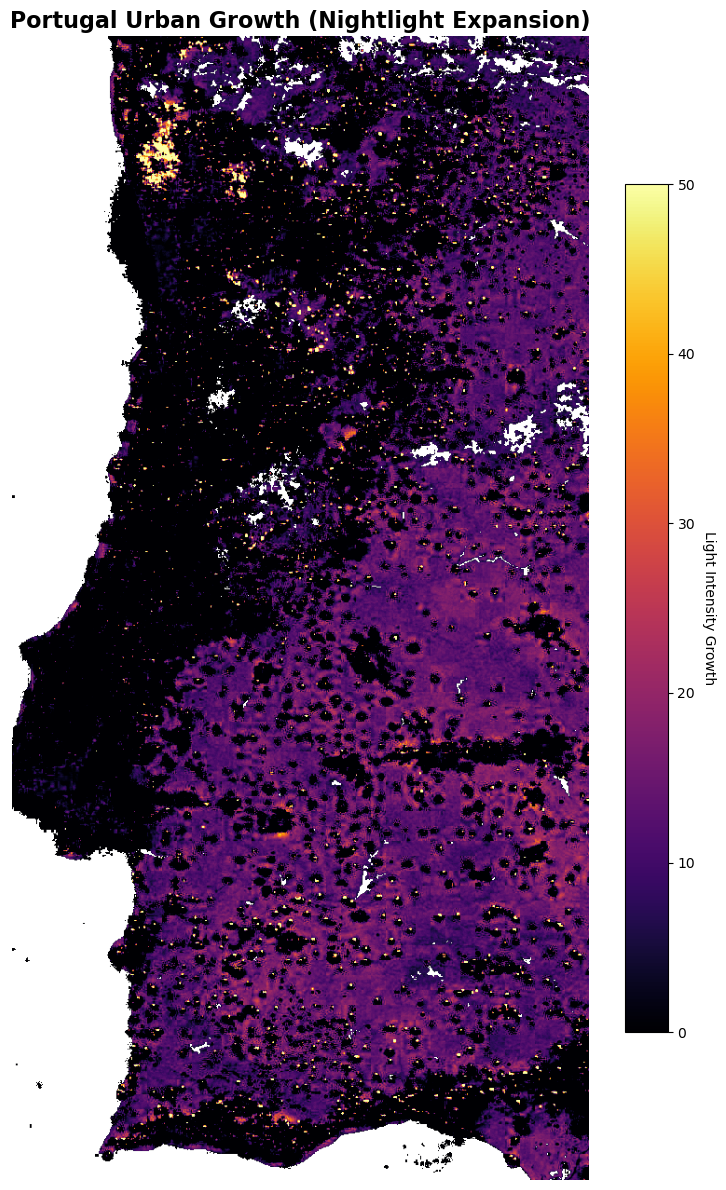

In [4]:
# Open the two GeoTIFFs we downloaded
with rasterio.open("data/lights_2012.tif") as src_2012:
    # Read the first band (brightness) and convert to float for math
    img_2012 = src_2012.read(1).astype(float) 

with rasterio.open("data/lights_2016.tif") as src_2016:
    img_2016 = src_2016.read(1).astype(float)

# Mathematically subtract 2012 from 2016 to find growth
growth_map = img_2016 - img_2012

# Clean the data: Ignore completely dark areas (oceans/deep forests)
# so the AI only calculates growth in populated regions
mask = (img_2012 > 10) | (img_2016 > 10)
growth_map = np.where(mask, growth_map, np.nan)

# Visualize the Growth Heatmap
fig, ax = plt.subplots(figsize=(10, 12))

# Use the 'inferno' colormap: Black = stable, Purple/Orange = moderate growth, Yellow = high growth
im = ax.imshow(growth_map, cmap='inferno', vmin=0, vmax=50)

ax.set_title("Portugal Urban Growth (Nightlight Expansion)", fontsize=16, fontweight='bold')
ax.axis("off")

# Add a colorbar legend
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Light Intensity Growth", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

## Step 4: AI-Driven Economic Zoning (Unsupervised Machine Learning)
While a standard heatmap shows us raw pixel changes, manually deciding what counts as "high growth" versus "low growth" introduces human bias. 

To make this analysis entirely data-driven, we can deploy an Unsupervised Machine Learning algorithm. Using `scikit-learn`, we feed the flat array of pixel growth into a **K-Means Clustering** model. The AI analyzes the data variance and automatically categorizes the country into three distinct, mathematically verified economic development tiers:
* **Zone 1:** Stagnant or declining light (Economic baseline)
* **Zone 2:** Moderate light expansion (Developing areas)
* **Zone 3:** Hyper-growth (Rapid urbanization and industrialization)

Running K-Means AI Clustering on Urban Growth...


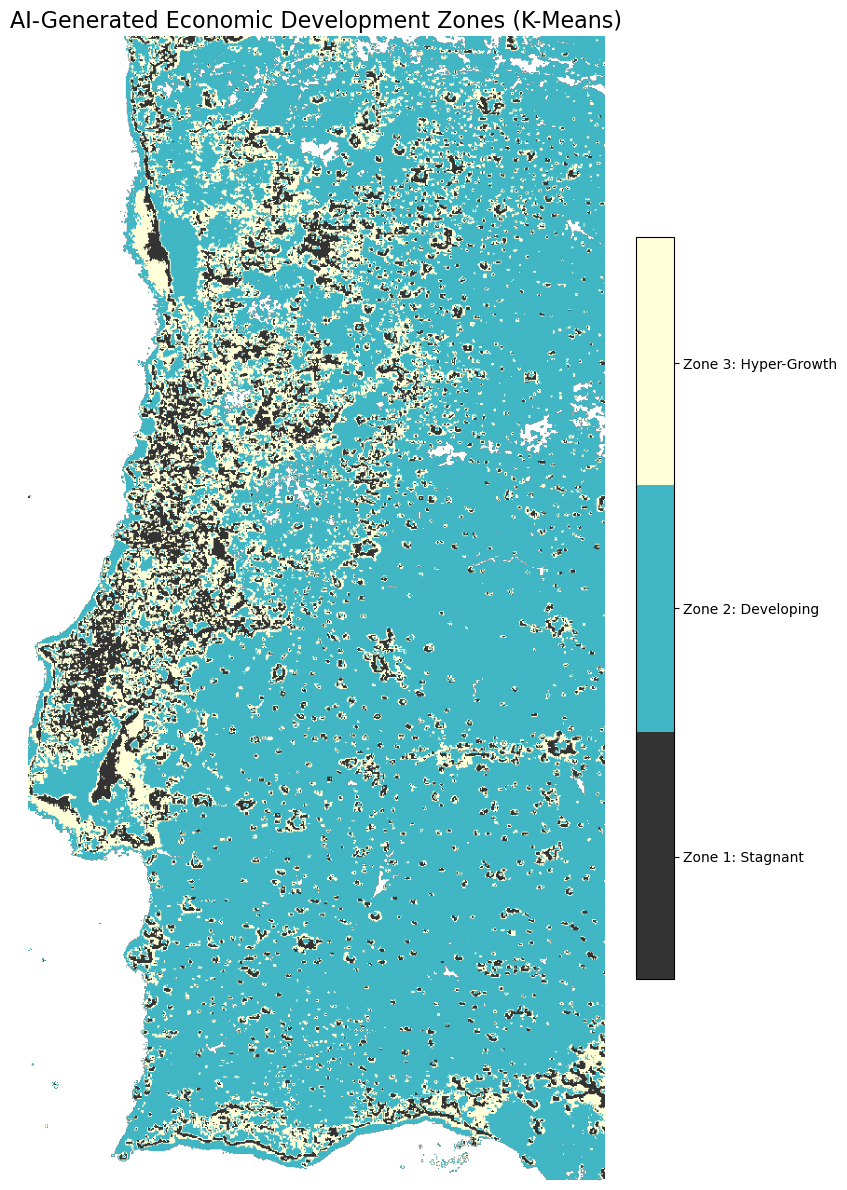

In [5]:
# Block 4: Machine Learning Clustering
from sklearn.cluster import KMeans
import numpy as np

print("Running K-Means AI Clustering on Urban Growth...")

# 1. Prepare the data: Remove NaNs and flatten the 2D map into a 1D list for the AI
valid_pixels = growth_map[~np.isnan(growth_map)]
X = valid_pixels.reshape(-1, 1)

# 2. Train the AI to find 3 distinct clusters of growth
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

# 3. Put the AI's labels back into the original 2D map shape
cluster_map = np.full(growth_map.shape, np.nan)
cluster_map[~np.isnan(growth_map)] = kmeans.labels_

# 4. Visualize the AI Clusters
fig, ax = plt.subplots(figsize=(10, 12))
# Custom colors: Dark grey (Stagnant), Light Blue (Developing), Yellow (Hyper-Growth)
cmap_ml = plt.matplotlib.colors.ListedColormap(['#333333', '#41b6c4', '#ffffd9'])

im = ax.imshow(cluster_map, cmap=cmap_ml)
ax.set_title("AI-Generated Economic Development Zones (K-Means)", fontsize=16)
ax.axis("off")

# Legend
cbar = plt.colorbar(im, ticks=[0.33, 1, 1.66], fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(['Zone 1: Stagnant', 'Zone 2: Developing', 'Zone 3: Hyper-Growth'])

plt.tight_layout()
plt.show()

## Interactive 3D Topography (Plotly)
A standard 2D map accurately displays geographic boundaries, but it struggles to convey the sheer magnitude of urban density. 

To solve this, we map the light radiance directly to the Z-axis using `plotly.graph_objects`. This transforms the flat numpy array into an interactive 3D surface model. Users can pan, zoom, and rotate the topography, where the highest "peaks" visually represent the densest concentrations of infrastructure and energy consumption (e.g., the Lisbon and Porto metropolitan areas).

In [6]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


Generating Interactive 3D Topography... (This might take a few seconds)


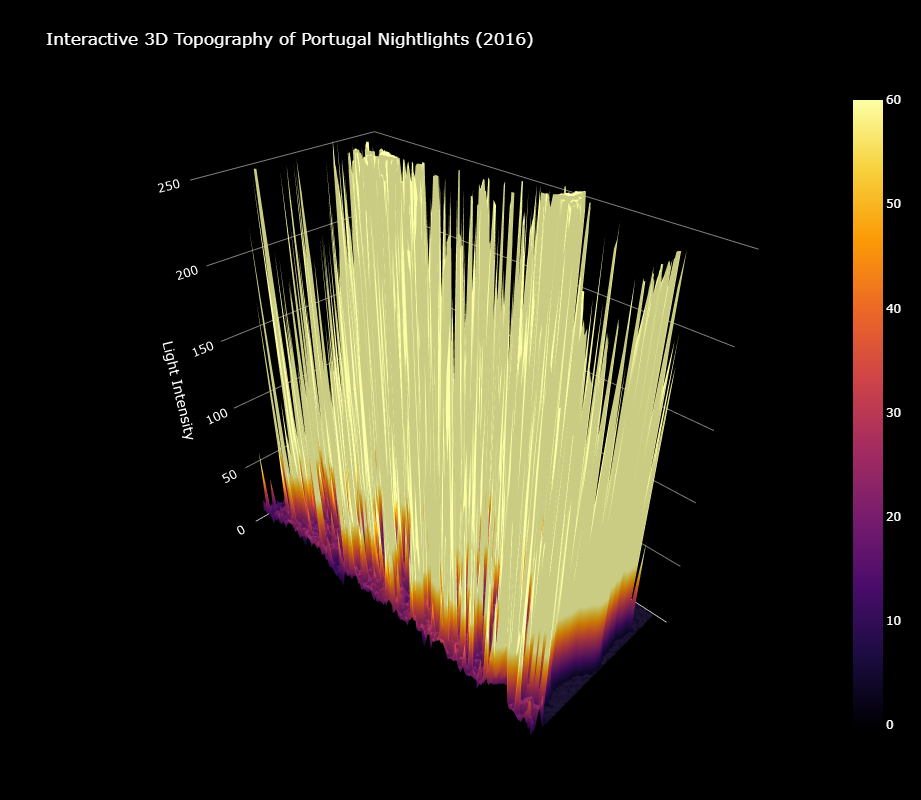

In [7]:
import plotly.graph_objects as go
import numpy as np

print("Generating Interactive 3D Topography... (This might take a few seconds)")

# Downsample the image so it runs smoothly in the browser (take every 5th pixel)
step = 5
z_data = img_2016[::step, ::step]

# Create the interactive 3D Surface Plot
fig = go.Figure(data=[go.Surface(
    z=z_data, 
    colorscale='inferno',
    cmin=0, 
    cmax=60,
    hovertemplate="Light Intensity: %{z}<extra></extra>"
)])

# Style the layout to make it look like a sleek night map
fig.update_layout(
    title='Interactive 3D Topography of Portugal Nightlights (2016)',
    autosize=False,
    width=900,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
    paper_bgcolor="black",
    font=dict(color="white"),
    scene=dict(
        xaxis=dict(visible=False), # Hide the grid lines for a cleaner look
        yaxis=dict(visible=False),
        zaxis=dict(title='Light Intensity', backgroundcolor="black", gridcolor="gray"),
        bgcolor="black"
    )
)

fig.show()